# EPS1 电机功率 — 深度分析
Hydraulic Systems Dataset | 100 Hz 采样 | 2205 周期 × 6000 点/周期 | 84 MB

电机功率直接反映泵负载。**预期对 Pump_Leakage 和 Accumulator 敏感。**
对比基线: PS1 (最强压力传感器) 和 VS1 (振动传感器)。

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import fft, signal, stats as sp_stats
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import cross_val_score, StratifiedKFold
from sklearn.metrics import confusion_matrix, classification_report
from sklearn.preprocessing import LabelEncoder
import os, gc, warnings
warnings.filterwarnings('ignore')

plt.rcParams['font.sans-serif'] = ['SimHei']
plt.rcParams['axes.unicode_minus'] = False
plt.rcParams['figure.dpi'] = 100

DATA_DIR = r'd:/for HS/dataset'
print('Libraries loaded.')

Libraries loaded.


## 模块 1：数据概览
加载 EPS1 + profile，按故障状态看功率分布。

In [2]:
profile = pd.read_csv(os.path.join(DATA_DIR, 'profile.txt'), sep='\t', header=None)
profile.columns = ['Cooler', 'Valve', 'Pump_Leakage', 'Accumulator', 'Stable']

eps1 = pd.read_csv(os.path.join(DATA_DIR, 'EPS1.txt'), sep='\t', header=None)
print(f'EPS1 shape: {eps1.shape[0]} cycles × {eps1.shape[1]} points')
print(f'Global range: [{eps1.values.min():.1f}, {eps1.values.max():.1f}] W')
print(f'Per-cycle mean: [{eps1.mean(axis=1).min():.1f}, {eps1.mean(axis=1).max():.1f}] W')
print(f'Per-cycle std:  [{eps1.std(axis=1).min():.1f}, {eps1.std(axis=1).max():.1f}] W')

# Per-fault motor power summary
fault_config = {
    'Cooler':       {100:'正常', 20:'降低', 3:'失效'},
    'Valve':        {100:'正常', 90:'轻微滞后', 80:'严重滞后', 73:'近失效'},
    'Pump_Leakage': {0:'无泄漏', 1:'轻微泄漏', 2:'严重泄漏'},
    'Accumulator':  {130:'正常130bar', 115:'微降115', 100:'严重100', 90:'近失效90'},
}

cycle_mean = eps1.mean(axis=1)
cycle_std  = eps1.std(axis=1)

for col, labels in fault_config.items():
    print(f'\n  {col}:')
    for val, name in labels.items():
        mask = profile[col] == val
        if mask.sum() > 0:
            print(f'    {name} ({val}): mean={cycle_mean[mask].mean():.1f} W, std={cycle_std[mask].mean():.1f} W, n={mask.sum()}')

EPS1 shape: 2205 cycles × 6000 points
Global range: [2097.8, 2995.2] W
Per-cycle mean: [2361.7, 2740.6] W


Per-cycle std:  [185.1, 294.0] W

  Cooler:
    正常 (100): mean=2548.9 W, std=188.1 W, n=741
    降低 (20): mean=2462.8 W, std=196.4 W, n=732
    失效 (3): mean=2474.1 W, std=226.1 W, n=732

  Valve:
    正常 (100): mean=2481.7 W, std=199.0 W, n=1125
    轻微滞后 (90): mean=2509.1 W, std=207.7 W, n=360
    严重滞后 (80): mean=2508.9 W, std=208.2 W, n=360
    近失效 (73): mean=2511.8 W, std=208.8 W, n=360

  Pump_Leakage:
    无泄漏 (0): mean=2467.5 W, std=195.2 W, n=1221
    轻微泄漏 (1): mean=2519.3 W, std=212.5 W, n=492
    严重泄漏 (2): mean=2541.2 W, std=215.0 W, n=492

  Accumulator:
    正常130bar (130): mean=2456.3 W, std=196.1 W, n=599
    微降115 (115): mean=2514.5 W, std=209.0 W, n=399
    严重100 (100): mean=2523.0 W, std=213.6 W, n=399
    近失效90 (90): mean=2501.7 W, std=201.3 W, n=808


## 模块 2：特征工程 (6000D → 31D)
复用 PS1-6 的 30 特征 + 追加 cycle_energy（功率积分）。

In [3]:
def extract_features(row, fs=100):
    """Extract 31 features from one 6000-point motor power cycle."""
    x = row.values if hasattr(row, 'values') else np.asarray(row, dtype=np.float64)
    n = len(x)
    feats = {}
    
    # Time-domain (10)
    feats['mean']   = np.mean(x)
    feats['std']    = np.std(x)
    feats['max']    = np.max(x)
    feats['min']    = np.min(x)
    feats['range']  = feats['max'] - feats['min']
    feats['rms']    = np.sqrt(np.mean(x**2))
    feats['crest']  = np.max(np.abs(x)) / feats['rms'] if feats['rms'] > 0 else 0
    feats['skew']   = sp_stats.skew(x)
    feats['kurt']   = sp_stats.kurtosis(x)
    feats['median'] = np.median(x)
    
    # 6-segment stats (12)
    seg_len = n // 6
    for s in range(6):
        seg = x[s*seg_len:(s+1)*seg_len]
        feats[f'seg{s+1}_mean'] = np.mean(seg)
        feats[f'seg{s+1}_std']  = np.std(seg)
    
    # Frequency domain (4)
    yf = fft.fft(x)
    xf = fft.fftfreq(n, d=1/fs)
    half = n // 2
    xf_half = xf[:half]
    amp = np.abs(yf[:half]) / n * 2
    
    dom_idx = np.argmax(amp[1:]) + 1
    feats['dom_freq'] = xf_half[dom_idx]
    feats['dom_amp']  = amp[dom_idx]
    
    total_power = np.sum(amp**2)
    if total_power > 0:
        feats['lf_ratio'] = np.sum(amp[(xf_half>=0.1)&(xf_half<5)]**2) / total_power
        feats['mf_ratio'] = np.sum(amp[(xf_half>=5)&(xf_half<20)]**2) / total_power
        feats['hf_ratio'] = np.sum(amp[(xf_half>=20)&(xf_half<=50)]**2) / total_power
    else:
        feats['lf_ratio'] = feats['mf_ratio'] = feats['hf_ratio'] = 0.0
    
    # Peak features (3)
    prominence = max(0.05 * np.std(x), 1e-6)
    peaks, _ = signal.find_peaks(x, distance=50, prominence=prominence)
    feats['n_peaks'] = len(peaks)
    feats['peak_mean_h'] = np.mean(x[peaks]) if len(peaks) > 0 else 0.0
    feats['peak_mean_gap'] = np.mean(np.diff(peaks)) if len(peaks) > 1 else 0.0
    
    # EPS1-specific: total energy per cycle (W·s = J)
    feats['cycle_energy'] = np.sum(x) / fs  # integral of power over 60s
    
    return pd.Series(feats)

print('Extracting features from EPS1...')
feats = eps1.apply(extract_features, axis=1)
print(f'Features: {feats.shape[0]} cycles × {feats.shape[1]} dims')
print(f'Feature list: {list(feats.columns)}')

# Downsampled curves for waveform plots
ds_curves = {}  # {fault: {state: {'mean':..., 'std':...}}}
for fault_col, states_dict in fault_config.items():
    ds_curves[fault_col] = {}
    for state in states_dict:
        mask = profile[fault_col] == state
        if mask.sum() > 0:
            raw = eps1[mask].values.astype(np.float64)
            n_cycles = raw.shape[0]
            down = raw.reshape(n_cycles, 60, 100).mean(axis=2)
            ds_curves[fault_col][state] = {
                'mean': down.mean(axis=0),
                'std':  down.std(axis=0)
            }


Extracting features from EPS1...


Features: 2205 cycles × 31 dims
Feature list: ['mean', 'std', 'max', 'min', 'range', 'rms', 'crest', 'skew', 'kurt', 'median', 'seg1_mean', 'seg1_std', 'seg2_mean', 'seg2_std', 'seg3_mean', 'seg3_std', 'seg4_mean', 'seg4_std', 'seg5_mean', 'seg5_std', 'seg6_mean', 'seg6_std', 'dom_freq', 'dom_amp', 'lf_ratio', 'mf_ratio', 'hf_ratio', 'n_peaks', 'peak_mean_h', 'peak_mean_gap', 'cycle_energy']


## 模块 3：故障分类 + 与 PS1 / VS1 / CE 对比
RF 5CV × 4 故障标签 → F1 柱状图 + 四故障特征重要性 (2×2) + 跨故障交叉分析。

In [ ]:
# ============================================================
# 模块 3：故障分类 + 传感器对比
# ============================================================
target_config = {
    'Cooler': [3, 20, 100],
    'Valve': [73, 80, 90, 100],
    'Pump_Leakage': [0, 1, 2],
    'Accumulator': [90, 100, 115, 130],
}

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
eps1_f1 = {}

print('EPS1  RF 5-fold CV  分类结果:')
print(f'{"故障":<18} {"F1":<8} {"± Std":<8}')
print('-' * 34)

for fault_col, classes in target_config.items():
    mask = profile[fault_col].isin(classes)
    X_sub = feats.loc[mask].values
    y_raw = profile.loc[mask, fault_col].values
    y_enc = LabelEncoder().fit_transform(y_raw)

    rf = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
    scores = cross_val_score(rf, X_sub, y_enc, cv=cv, scoring='f1_weighted')
    eps1_f1[fault_col] = scores.mean()
    print(f'{fault_col:<18} {scores.mean():.4f}   ±{scores.std():.4f}')

# 基线（来自之前 PS1 / VS1 / CE 分析，便于横向对比）
ps1_f1 = {'Cooler': 0.9932, 'Valve': 0.9932, 'Pump_Leakage': 0.9818, 'Accumulator': 0.9823}
vs1_f1 = {'Cooler': 0.9559, 'Valve': 0.3500, 'Pump_Leakage': 0.5932, 'Accumulator': 0.4189}
ce_f1  = {'Cooler': 0.9999, 'Valve': 0.3516, 'Pump_Leakage': 0.5563, 'Accumulator': 0.5491}

print(f'\nEPS1 最强: {max(eps1_f1, key=eps1_f1.get)} (F1={max(eps1_f1.values()):.4f})')
print(f'EPS1 最弱: {min(eps1_f1, key=eps1_f1.get)} (F1={min(eps1_f1.values()):.4f})')

In [ ]:
# -------- 4 传感器 F1 对比柱状图 --------
fig, ax = plt.subplots(figsize=(12, 5))
x = np.arange(4)
w = 0.2

sensors = [
    ('EPS1', eps1_f1, '#4575b4'),
    ('PS1',  ps1_f1,  '#d73027'),
    ('VS1',  vs1_f1,  '#9e9e9e'),
    ('CE',   ce_f1,   '#4daf4a'),
]

for idx, (name, f1_dict, color) in enumerate(sensors):
    vals = [f1_dict[t] for t in target_config]
    bars = ax.bar(x + idx*w, vals, w, label=name, color=color, edgecolor='white')
    for bar, val in zip(bars, vals):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.008,
                f'{val:.3f}', ha='center', va='bottom', fontsize=6.5)

ax.set_xticks(x + 1.5*w)
ax.set_xticklabels(list(target_config.keys()), fontsize=11)
ax.set_ylabel('F1 Weighted')
ax.set_title('EPS1 vs PS1 vs VS1 vs CE — 故障分类能力对比', fontsize=14)
ax.legend(fontsize=9)
ax.set_ylim(0, 1.12)
ax.grid(True, alpha=0.3, axis='y')
plt.tight_layout()
plt.show()

# -------- 四故障特征重要性（2×2）--------
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fault_names_cn = {'Cooler': '冷却器', 'Valve': '阀门', 'Pump_Leakage': '泵泄漏', 'Accumulator': '蓄能器'}

for ax, fault_col in zip(axes.flat, target_config):
    mask = profile[fault_col].isin(target_config[fault_col])
    X_sub = feats.loc[mask].values
    y_raw = profile.loc[mask, fault_col].values
    y_enc = LabelEncoder().fit_transform(y_raw)

    rf = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
    rf.fit(X_sub, y_enc)
    imp = pd.Series(rf.feature_importances_, index=feats.columns).sort_values()
    top10 = imp.tail(10)

    colors = ['#d73027' if 'seg' in f else '#4575b4' for f in top10.index]
    ax.barh(top10.index, top10.values, color=colors, edgecolor='white')
    ax.set_title(f'{fault_names_cn[fault_col]} ({fault_col})  F1={eps1_f1[fault_col]:.4f}', fontsize=12)
    ax.set_xlabel('Importance')
    ax.grid(True, alpha=0.3, axis='x')

plt.suptitle('EPS1 特征重要性 Top-10 — 按故障类型（红=分段特征, 蓝=全局特征）', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

# -------- 跨故障特征交叉 --------
print('跨故障 Top-3 共用特征:')
common = {}
for fault_col in target_config:
    mask = profile[fault_col].isin(target_config[fault_col])
    X_sub = feats.loc[mask].values
    y_raw = profile.loc[mask, fault_col].values
    y_enc = LabelEncoder().fit_transform(y_raw)
    rf = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
    rf.fit(X_sub, y_enc)
    top3 = set(pd.Series(rf.feature_importances_, index=feats.columns).nlargest(3).index)
    for feat in top3:
        common[feat] = common.get(feat, 0) + 1

found = False
for feat, count in sorted(common.items(), key=lambda x: -x[1]):
    if count >= 2:
        print(f'  {feat}: {count}/4 故障共用')
        found = True
if not found:
    print('  (无共用特征 — 每种故障有独立的特征指纹)')

## 模块 4：降采样波形分析
6000 点 → 60 点（每秒均值）。按故障状态分组，看功率曲线的差异。

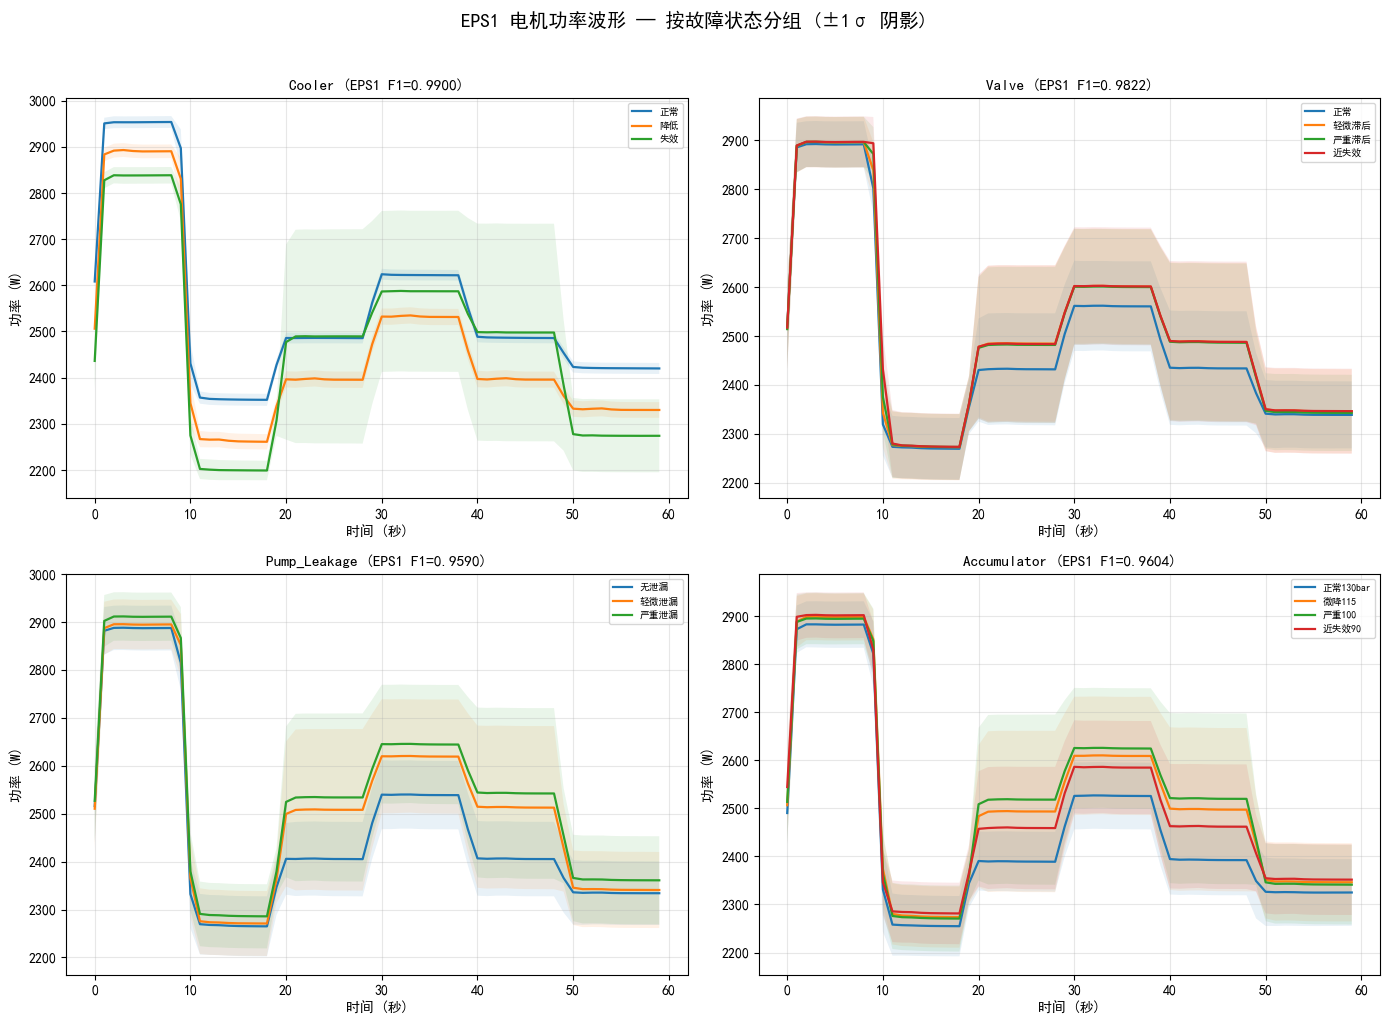


三阶段功率分析 (0-19s / 20-39s / 40-59s):

  Cooler:
    正常: start=2641W  mid=2554W  end=2452W
    降低: start=2562W  mid=2464W  end=2362W
    失效: start=2504W  mid=2538W  end=2380W

  Valve:
    正常: start=2564W  mid=2497W  end=2384W
    轻微滞后: start=2571W  mid=2543W  end=2414W
    严重滞后: start=2574W  mid=2541W  end=2412W


    近失效: start=2579W  mid=2543W  end=2414W

  Pump_Leakage:
    无泄漏: start=2562W  mid=2473W  end=2368W
    轻微泄漏: start=2571W  mid=2564W  end=2423W
    严重泄漏: start=2586W  mid=2589W  end=2448W

  Accumulator:
    正常130bar: start=2554W  mid=2458W  end=2357W
    微降115: start=2573W  mid=2551W  end=2419W
    严重100: start=2571W  mid=2571W  end=2427W


    近失效90: start=2578W  mid=2522W  end=2405W


In [6]:
time = np.arange(0, 60)

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
for ax, (fault_col, labels) in zip(axes.flat, fault_config.items()):
    ds = ds_curves[fault_col]
    for state, name in labels.items():
        if state in ds:
            ax.plot(time, ds[state]['mean'], linewidth=1.6, label=name)
            ax.fill_between(time,
                            ds[state]['mean']-ds[state]['std'],
                            ds[state]['mean']+ds[state]['std'],
                            alpha=0.1)
    ax.set_title(f'{fault_col} (EPS1 F1={eps1_f1[fault_col]:.4f})', fontsize=11)
    ax.set_xlabel('时间 (秒)')
    ax.set_ylabel('功率 (W)')
    ax.legend(fontsize=7)
    ax.grid(True, alpha=0.3)
plt.suptitle('EPS1 电机功率波形 — 按故障状态分组 (±1σ 阴影)', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

# Phase analysis: 3 segments of the cycle
print('\n三阶段功率分析 (0-19s / 20-39s / 40-59s):')
segments = [(0, 20, '启动段'), (20, 40, '中段'), (40, 60, '末段')]
for fault_col, labels in fault_config.items():
    print(f'\n  {fault_col}:')
    for state, name in labels.items():
        mask = profile[fault_col] == state
        if mask.sum() > 0:
            seg_means = []
            for start, end, _ in segments:
                seg_means.append(eps1[mask].iloc[:, start*100:end*100].values.mean())
            print(f'    {name}: start={seg_means[0]:.0f}W  mid={seg_means[1]:.0f}W  end={seg_means[2]:.0f}W')

## 模块 5：频域分析
100 Hz → Nyquist=50 Hz。电机功率的频谱特征与故障的关联。

Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.


Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.


Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.


Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.


Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.


Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.


Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.


Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.


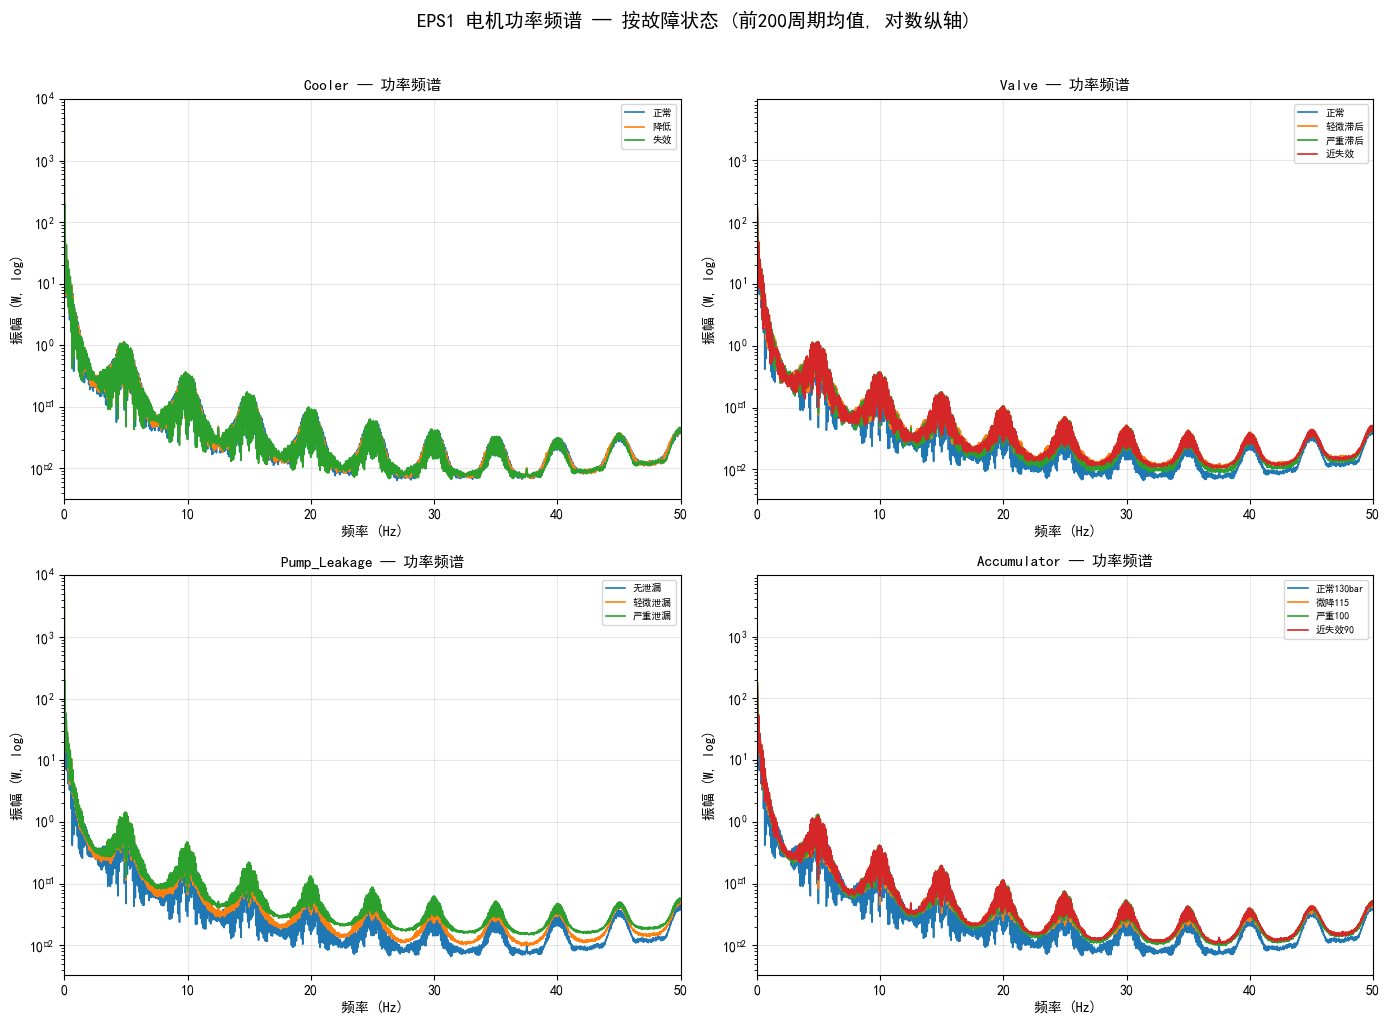

In [7]:
# FFT spectra by fault state (Cooler shown)
fs = 100
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

for ax, (fault_col, labels) in zip(axes.flat, fault_config.items()):
    for state, name in labels.items():
        mask = profile[fault_col] == state
        if mask.sum() > 0:
            samples = eps1[mask].iloc[:200]
            spectra = []
            for idx in range(len(samples)):
                x = samples.iloc[idx].values.astype(np.float64)
                n = len(x)
                yf = fft.fft(x)
                xf = fft.fftfreq(n, d=1/fs)
                half = n // 2
                amp = np.abs(yf[:half]) / n * 2
                spectra.append(amp)
            mean_spec = np.mean(spectra, axis=0)
            ax.semilogy(xf[:half], mean_spec, linewidth=1.2, label=name)
    ax.set_title(f'{fault_col} — 功率频谱', fontsize=11)
    ax.set_xlabel('频率 (Hz)')
    ax.set_ylabel('振幅 (W, log)')
    ax.legend(fontsize=7)
    ax.grid(True, alpha=0.3)
    ax.set_xlim(0, 50)
plt.suptitle('EPS1 电机功率频谱 — 按故障状态 (前200周期均值, 对数纵轴)', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

## 模块 6：周期能量与退化追踪
每周期总功（功率积分）随周期数演变 + 状态切换响应。

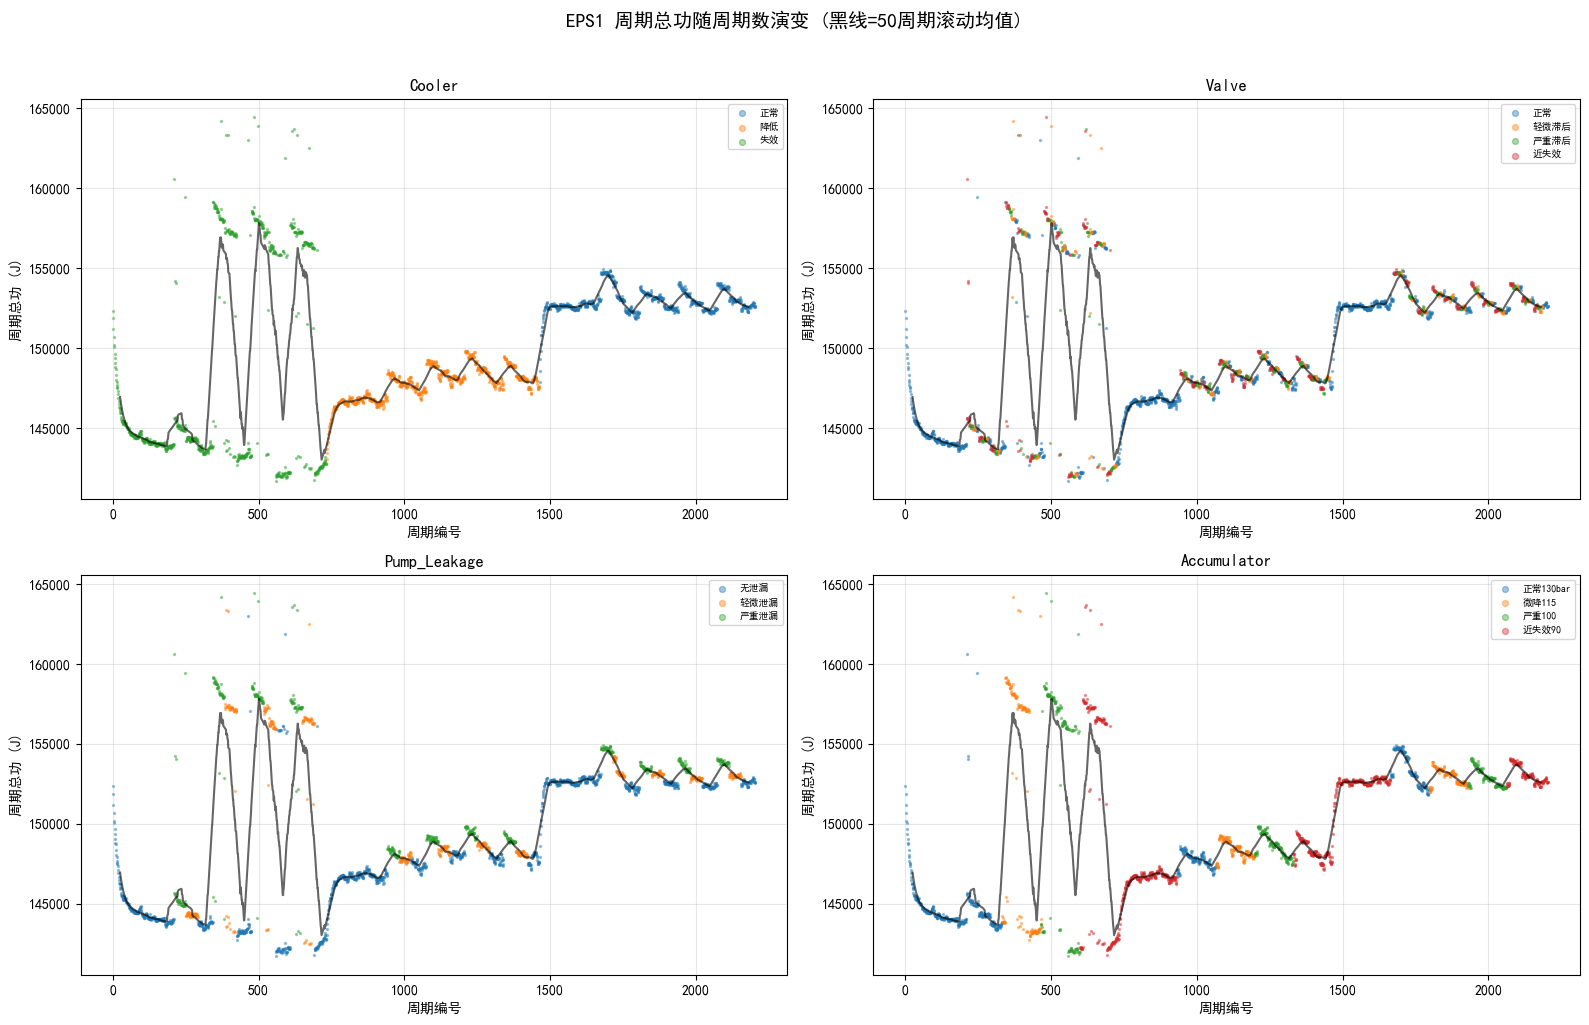

Cooler: 2 switches, 1st at cycle 731, energy jump = +1981 J
Valve: 144 switches, 1st at cycle 210, energy jump = +2467 J
Pump_Leakage: 36 switches, 1st at cycle 209, energy jump = +2446 J
Accumulator: 11 switches, 1st at cycle 332, energy jump = +8847 J


In [9]:
# Per-cycle energy over time, colored by fault state
cycle_energy = feats['cycle_energy'].values
cycle_idx = np.arange(len(cycle_energy))
rolling_energy = pd.Series(cycle_energy).rolling(window=50, center=True).mean()

fig, axes = plt.subplots(2, 2, figsize=(16, 10))
for ax, (fault_col, labels) in zip(axes.flat, fault_config.items()):
    for state, name in labels.items():
        mask = profile[fault_col] == state
        if mask.sum() > 0:
            ax.scatter(cycle_idx[mask], cycle_energy[mask], s=2, alpha=0.4, label=name)
    ax.plot(cycle_idx, rolling_energy, 'black', linewidth=1.5, alpha=0.6)
    ax.set_xlabel('周期编号')
    ax.set_ylabel('周期总功 (J)')
    ax.set_title(f'{fault_col}')
    ax.legend(fontsize=7, markerscale=3)
    ax.grid(True, alpha=0.3)
plt.suptitle('EPS1 周期总功随周期数演变 (黑线=50周期滚动均值)', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

# State-switch response: energy jump at transitions
for fault_col in ['Cooler', 'Valve', 'Pump_Leakage', 'Accumulator']:
    vals = profile[fault_col].values
    switches = np.where(np.diff(vals) != 0)[0]
    if len(switches) > 0 and switches[0] >= 30 and switches[0] + 30 < len(cycle_energy):
        sp = switches[0]  # first switch
        before = cycle_energy[sp-30:sp].mean()
        after  = cycle_energy[sp:sp+30].mean()
        print(f'{fault_col}: {len(switches)} switches, 1st at cycle {sp}, energy jump = {after-before:+.0f} J')

## 模块 7：总结

In [10]:
print('=' * 65)
print('EPS1 电机功率分析 — 总结')
print('=' * 65)
print()
print('1. EPS1 故障分类 F1 (RF 5CV):')
for t in target_config:
    print(f'   {t:<14}: {eps1_f1[t]:.4f}')
print()
print('2. 三传感器对比 (EPS1 vs PS1 vs VS1):')
print(f'   {"Fault":<16} {"EPS1":<8} {"PS1":<8} {"VS1":<8} {"Best":<8}')
print(f'   {"-"*48}')
for t in target_config:
    best_name = max([('EPS1', eps1_f1[t]), ('PS1', ps1_f1[t]), ('VS1', vs1_f1[t])], key=lambda x: x[1])[0]
    print(f'   {t:<16} {eps1_f1[t]:.4f}   {ps1_f1[t]:.4f}   {vs1_f1[t]:.4f}   {best_name}')
print()
print('3. 关键发现:')
best_eps1 = max(eps1_f1, key=eps1_f1.get)
print(f'   - EPS1 最擅长: {best_eps1} (F1={eps1_f1[best_eps1]:.4f})')
worst_eps1 = min(eps1_f1, key=eps1_f1.get)
print(f'   - EPS1 最不擅长: {worst_eps1} (F1={eps1_f1[worst_eps1]:.4f})')
for t in target_config:
    if eps1_f1[t] > ps1_f1[t]:
        print(f'   - EPS1 > PS1 在 {t} ({eps1_f1[t]:.4f} vs {ps1_f1[t]:.4f})')
ce_better = sum(1 for t in target_config if ce_f1[t] > eps1_f1[t])
print(f'   - CE 在 {ce_better}/4 故障上优于 EPS1 (CE是虚拟传感器!)')
print()
print('=' * 65)
print('Analysis complete.')

EPS1 电机功率分析 — 总结

1. EPS1 故障分类 F1 (RF 5CV):
   Cooler        : 0.9900
   Valve         : 0.9822
   Pump_Leakage  : 0.9590
   Accumulator   : 0.9604

2. 三传感器对比 (EPS1 vs PS1 vs VS1):
   Fault            EPS1     PS1      VS1      Best    
   ------------------------------------------------
   Cooler           0.9900   0.9932   0.9559   PS1
   Valve            0.9822   0.9932   0.3500   PS1
   Pump_Leakage     0.9590   0.9818   0.5932   PS1
   Accumulator      0.9604   0.9823   0.4189   PS1

3. 关键发现:
   - EPS1 最擅长: Cooler (F1=0.9900)
   - EPS1 最不擅长: Pump_Leakage (F1=0.9590)
   - CE 在 1/4 故障上优于 EPS1 (CE是虚拟传感器!)

Analysis complete.
